In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
from IPython.display import clear_output
import nibabel as nib

import matplotlib.dates as mdates

import seaborn as sns
import numpy as np
import shutil
import SimpleITK as sitk

In [2]:
plot_detail = "Bilateral Test Data"
figure_save_dir = "figures_bilateral_test_data"

In [3]:
data = '/Users/kamleshranabhat/Documents/nii_images/metadata_csv/bilateral_test_patients.csv'
df = pd.read_csv(data)  # or errors='ignore'

df_unique = df.drop_duplicates(subset='DirName', keep='first')
print("Total number of unique rows:", len(df_unique))

Total number of unique rows: 62


In [4]:
import pandas as pd

data = "/Users/kamleshranabhat/Documents/nii_images/metadata_csv/bilateral_test_patients.csv"
df = pd.read_csv(data)

# Keep only rows where PatientAge matches pattern like '046Y'
df = df[df['PatientAge'].str.match(r'^\d{3}Y$', na=False)]

# Strip 'Y' and convert to float
df['PatientAge'] = df['PatientAge'].str.rstrip('Y').astype(float)

# Filter out patients under 18
df = df[df['PatientAge'] >= 18]

# Drop duplicate DirName entries
df_unique = df.drop_duplicates(subset='DirName', keep='first')

print("Total number of unique rows:", len(df_unique))

Total number of unique rows: 60


In [5]:
# # Clean and convert PatientAge to numeric (if it's like "017Y", "34Y", etc.)
# df_unique['PatientAge'] = df_unique['PatientAge'].astype(str).str.extract(r'(\d+)').astype(float)

# # Filter patients under 18
# underage_patients = df_unique[df_unique['PatientAge'] < 18]

# # Display result
# print(underage_patients[["DirName", "PatientAge"]])

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2023611139.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['AcquisitionDate'] = pd.to_datetime(df_unique['AcquisitionDate'], format='%Y%m%d')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2023611139.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="AcquisitionDate", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2023611139.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt

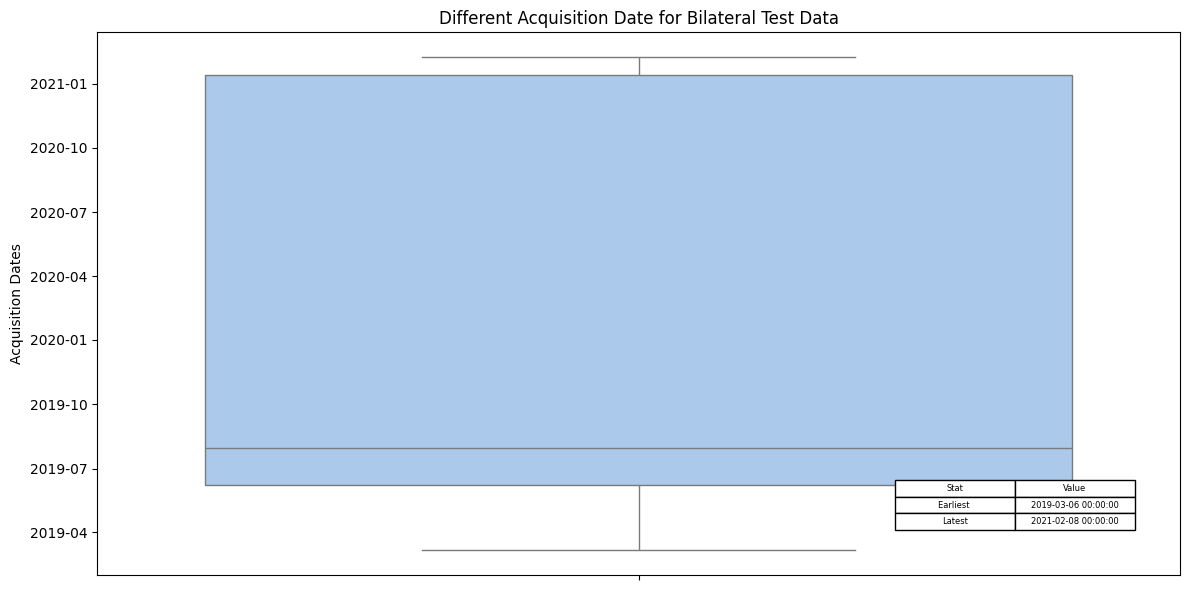

In [6]:
df_unique['AcquisitionDate'] = pd.to_datetime(df_unique['AcquisitionDate'], format='%Y%m%d')
earliest = min(df_unique['AcquisitionDate'])
latest = max(df_unique['AcquisitionDate'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="AcquisitionDate", palette='pastel')

# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Earliest ', 'Latest'],
    'Value': [earliest, latest]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.05, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

title_name = f'Different Acquisition Date for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('Acquisition Dates')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()


/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/587934789.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['NumericAge'] = df_unique['PatientAge'].astype(str).str.extract(r'(\d+)').astype(float)
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/587934789.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_age_clean, y="NumericAge", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/587934789.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  p

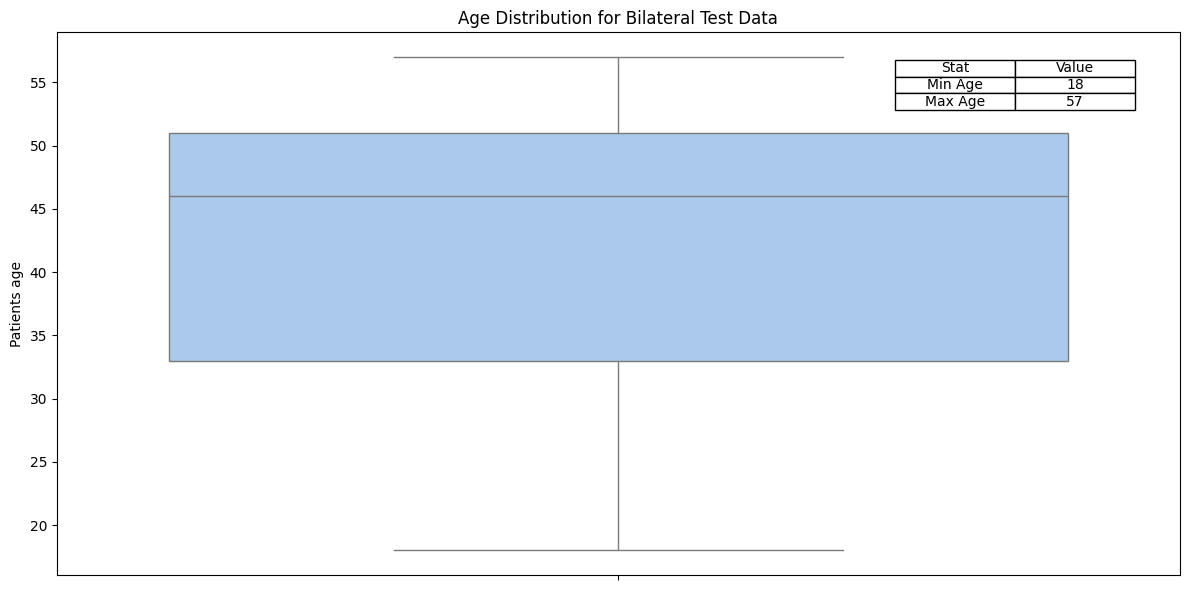

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.transforms import Bbox

# Count occurrences of each gender
gender_counts = df_unique['PatientSex'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

# Extract numeric age after ensuring PatientAge is string
df_unique['NumericAge'] = df_unique['PatientAge'].astype(str).str.extract(r'(\d+)').astype(float)

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['NumericAge'])

# Calculate min and max age
min_age = df_age_clean['NumericAge'].min()
max_age = df_age_clean['NumericAge'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_age_clean, y="NumericAge", palette='pastel')

# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min Age', 'Max Age'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
title_name = f'Age Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('Patients age')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Count occurrences of each gender
# gender_counts = df_unique['PatientSex'].value_counts().reset_index()
# gender_counts.columns = ['Gender', 'Count']

# # Extract numeric age
# df_unique['NumericAge'] = df_unique['PatientAge'].str.extract(r'(\d+)').astype(float)

# # Drop NaN ages
# df_age_clean = df_unique.dropna(subset=['NumericAge'])

# # Calculate min and max age
# min_age = df_age_clean['NumericAge'].min()
# max_age = df_age_clean['NumericAge'].max()

# # Plotting
# fig, ax = plt.subplots(figsize=(12, 6))
# sns.boxplot(data=df_unique, y="NumericAge", palette='pastel')
# # Create a separate table figure (inset)
# age_table = pd.DataFrame({
#     'Stat': ['Min Age', 'Max Age'],
#     'Value': [int(min_age), int(max_age)]
# })

# # Add table as a new axes
# from matplotlib.transforms import Bbox
# bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
# table_ax = fig.add_axes(bbox)
# table_ax.axis('off')
# table_ax.table(cellText=age_table.values,
#                colLabels=age_table.columns,
#                cellLoc='center',
#                colLoc='center',
#                loc='center')

# # Final labels and layout
# # ax.set_title('Age Distribution')
# # ax.set_ylabel('Patients age')
# # plt.tight_layout()
# # plt.show()

# title_name = 'Age Distribution for 1200 Knee Model'
# ax.set_title(title_name)
# ax.set_ylabel('Patients age')

# # Save the figure
# safe_title = title_name.replace(" ", "_")
# plt.tight_layout()
# plt.savefig(f"./figures_knee_model/{safe_title}.jpg", dpi=300)
# plt.show()

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/1071212851.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_counts, x='Gender', y='Count', palette='pastel')


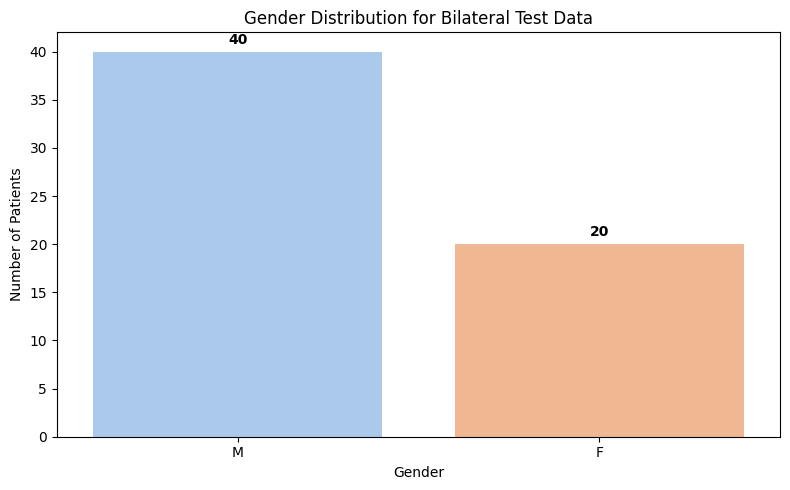

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count occurrences of each gender
gender_counts = df_unique['PatientSex'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

# Extract numeric age
# df_unique['NumericAge'] = df_unique['PatientAge'].str.extract(r'(\d+)').astype(float)


# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['NumericAge'])

# Calculate min and max age
min_age = df_age_clean['NumericAge'].min()
max_age = df_age_clean['NumericAge'].max()

# Plotting
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_counts, x='Gender', y='Count', palette='pastel')

# Add count labels on top of bars
for i, row in gender_counts.iterrows():
    ax.text(i, row['Count'] + 0.5, int(row['Count']), ha='center', va='bottom', fontsize=10, fontweight='bold')

# plt.title('Gender Distribution with Age Stats')
# plt.xlabel('Gender')
# plt.ylabel('Number of Patients')
# plt.tight_layout()
# plt.show()
    
title_name = f'Gender Distribution for {plot_detail}'
ax.set_title(title_name)
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()




/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/3435976521.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['AcquisitionDate'] = pd.to_datetime(df_unique['AcquisitionDate'], format='%Y%m%d')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/3435976521.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Manufacturer", y="Count", data=manufacturer_counts, palette='Set2', ax=ax)


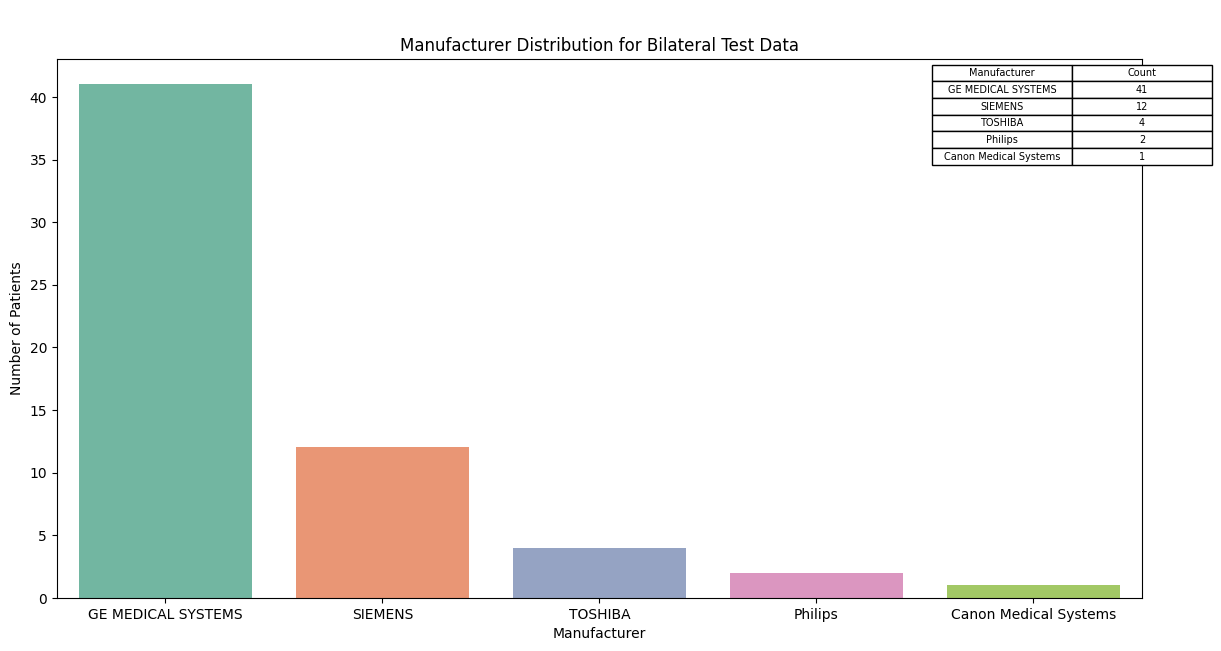

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox

# Parse date
df_unique['AcquisitionDate'] = pd.to_datetime(df_unique['AcquisitionDate'], format='%Y%m%d')
earliest = df_unique['AcquisitionDate'].min()
latest = df_unique['AcquisitionDate'].max()

# Count the number of records per manufacturer
manufacturer_counts = df_unique['Manufacturer'].value_counts().reset_index()
manufacturer_counts.columns = ['Manufacturer', 'Count']

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x="Manufacturer", y="Count", data=manufacturer_counts, palette='Set2', ax=ax)

# Create table inset with manufacturer counts
bbox = Bbox.from_bounds(0.75, 0.65, 0.2, 0.3)  # Slightly bigger to accommodate more rows
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=manufacturer_counts.values,
               colLabels=manufacturer_counts.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Labels and save
title_name = f'Manufacturer Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Number of Patients')

safe_title = title_name.replace(" ", "_")
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

In [11]:
# headers = [
#     "DirName", "PatientID", "SeriesNumber", "PatientBirthDate", "PatientSex", "PatientAge", "Manufacturer",
#     "AcquisitionDate", "Exposure", "ExposureTime", "XRayTubeCurrent", "PixelSpacing", "ReconstructionDiameter",
#     "SliceThickness", "RescaleIntercept", "SmallestImagePixelValue", "LargestImagePixelValue", "KVP", "Rows"
# ]

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2866276682.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="Exposure", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2866276682.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Total number of unique rows: 61


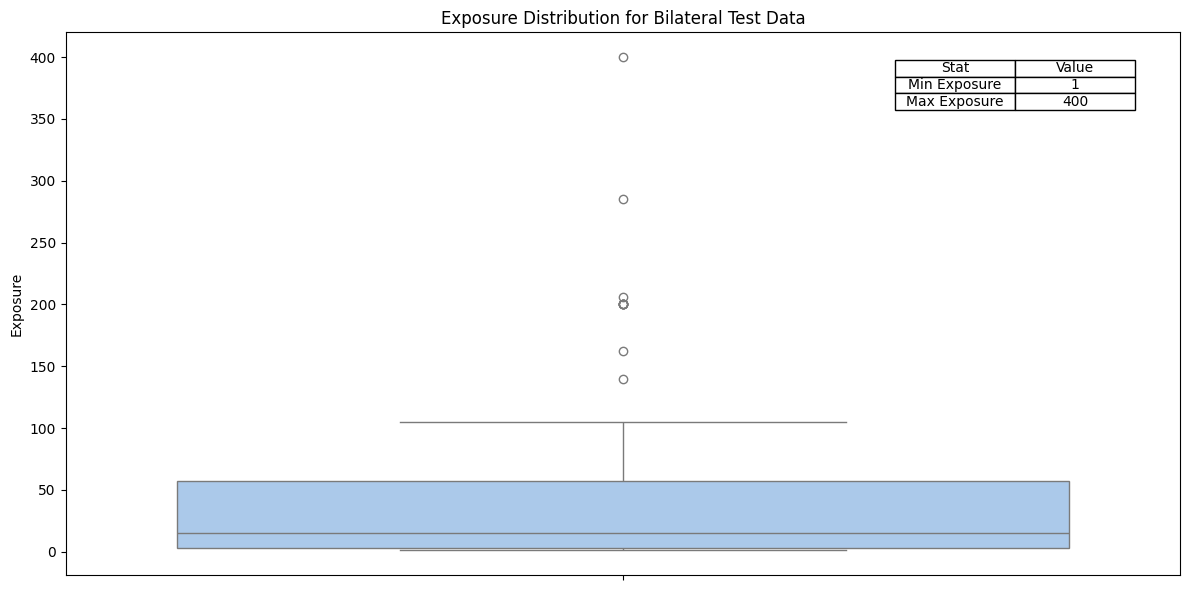

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Extract numeric age
df_unique = df.drop_duplicates(subset='PatientID', keep='first')
print("Total number of unique rows:", len(df_unique))

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['Exposure'])

# Calculate min and max age
min_age = df_age_clean['Exposure'].min()
max_age = df_age_clean['Exposure'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="Exposure", palette='pastel')
# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min Exposure', 'Max Exposure'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
# ax.set_title('Age Distribution')
# ax.set_ylabel('Patients age')
# plt.tight_layout()
# plt.show()

title_name = f'Exposure Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('Exposure')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

Total number of unique rows: 61


/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2118392834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="ExposureTime", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2118392834.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


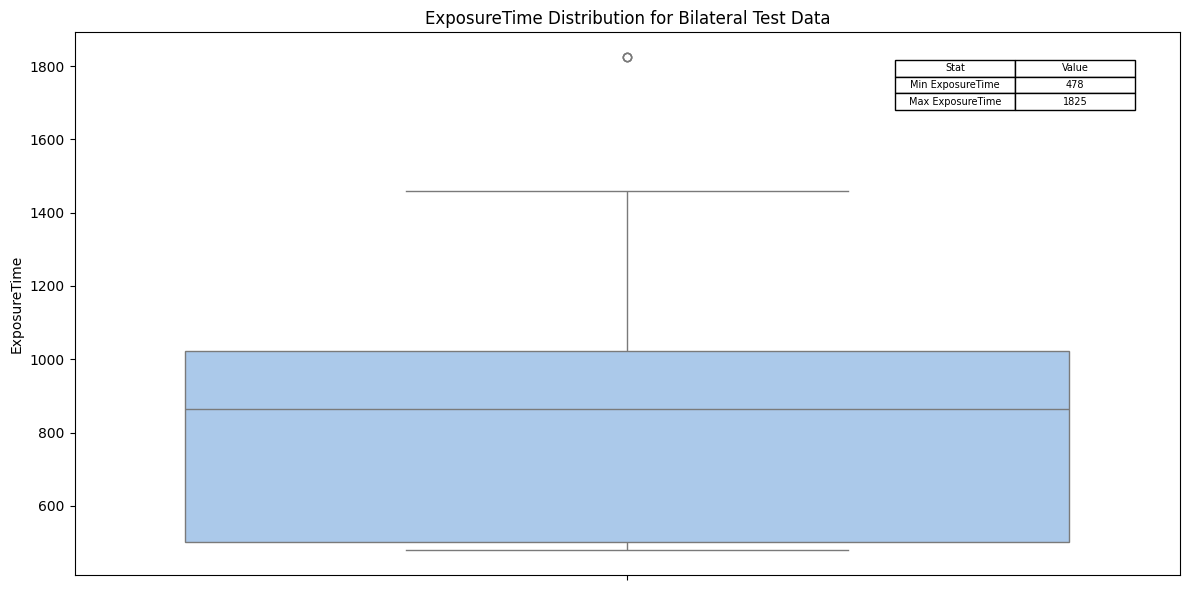

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Extract numeric age
df_unique = df.drop_duplicates(subset='PatientID', keep='first')
print("Total number of unique rows:", len(df_unique))

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['ExposureTime'])

# Calculate min and max age
min_age = df_age_clean['ExposureTime'].min()
max_age = df_age_clean['ExposureTime'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="ExposureTime", palette='pastel')
# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min ExposureTime', 'Max ExposureTime'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
# ax.set_title('Age Distribution')
# ax.set_ylabel('Patients age')
# plt.tight_layout()
# plt.show()

title_name = f'ExposureTime Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('ExposureTime')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

In [14]:
# headers = [
#     "DirName", "PatientID", "SeriesNumber", "PatientBirthDate", "PatientSex", "PatientAge", "Manufacturer",
#     "AcquisitionDate", "Exposure", "ExposureTime", "XRayTubeCurrent", "PixelSpacing", "ReconstructionDiameter",
#     "SliceThickness", "RescaleIntercept", "SmallestImagePixelValue", "LargestImagePixelValue", "KVP", "Rows"
# ]

Total number of unique rows: 61


/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/324559614.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="XRayTubeCurrent", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/324559614.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


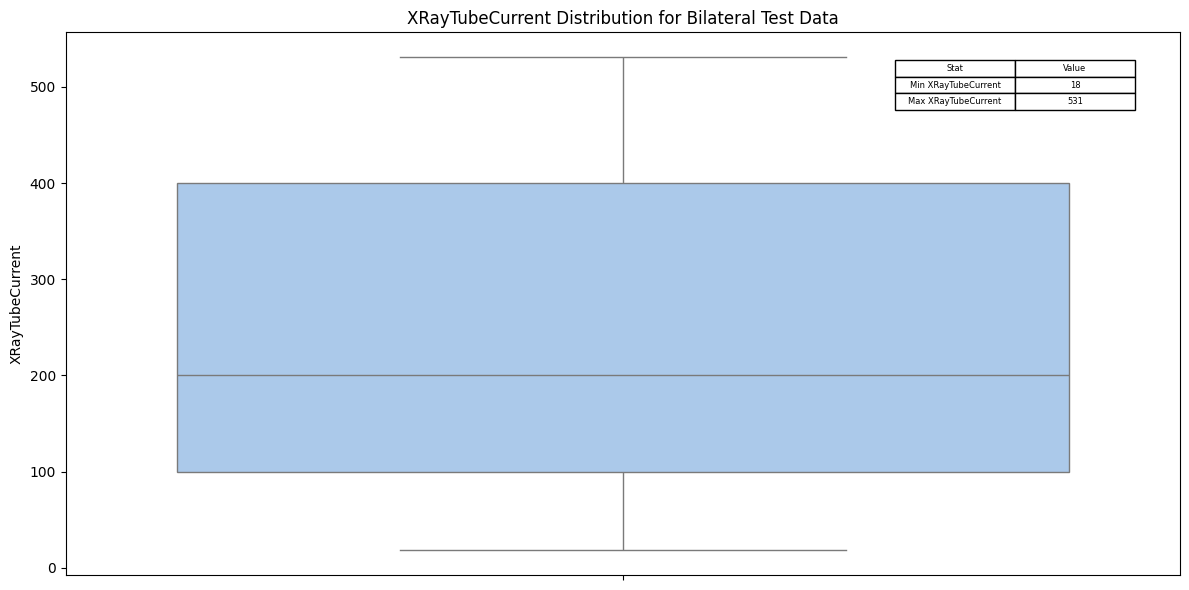

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Extract numeric age
df_unique = df.drop_duplicates(subset='PatientID', keep='first')
print("Total number of unique rows:", len(df_unique))

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['XRayTubeCurrent'])

# Calculate min and max age
min_age = df_age_clean['XRayTubeCurrent'].min()
max_age = df_age_clean['XRayTubeCurrent'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="XRayTubeCurrent", palette='pastel')
# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min XRayTubeCurrent', 'Max XRayTubeCurrent'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
# ax.set_title('Age Distribution')
# ax.set_ylabel('Patients age')
# plt.tight_layout()
# plt.show()

title_name = f'XRayTubeCurrent Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('XRayTubeCurrent')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

Total number of unique rows: 61


/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/661009750.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="ReconstructionDiameter", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/661009750.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


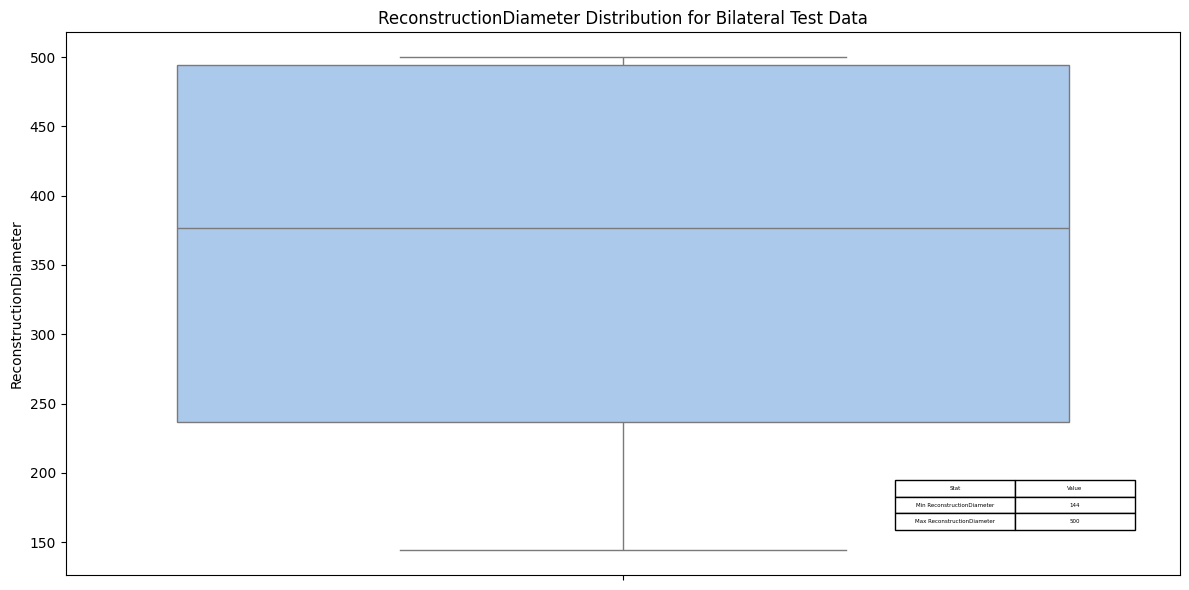

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Extract numeric age
df_unique = df.drop_duplicates(subset='PatientID', keep='first')
print("Total number of unique rows:", len(df_unique))

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['ReconstructionDiameter'])

# Calculate min and max age
min_age = df_age_clean['ReconstructionDiameter'].min()
max_age = df_age_clean['ReconstructionDiameter'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="ReconstructionDiameter", palette='pastel')
# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min ReconstructionDiameter', 'Max ReconstructionDiameter'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.05, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
# ax.set_title('Age Distribution')
# ax.set_ylabel('Patients age')
# plt.tight_layout()
# plt.show()

title_name = f'ReconstructionDiameter Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('ReconstructionDiameter')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

Total number of unique rows: 61


/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/285512266.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_unique, y="SliceThickness", palette='pastel')
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/285512266.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


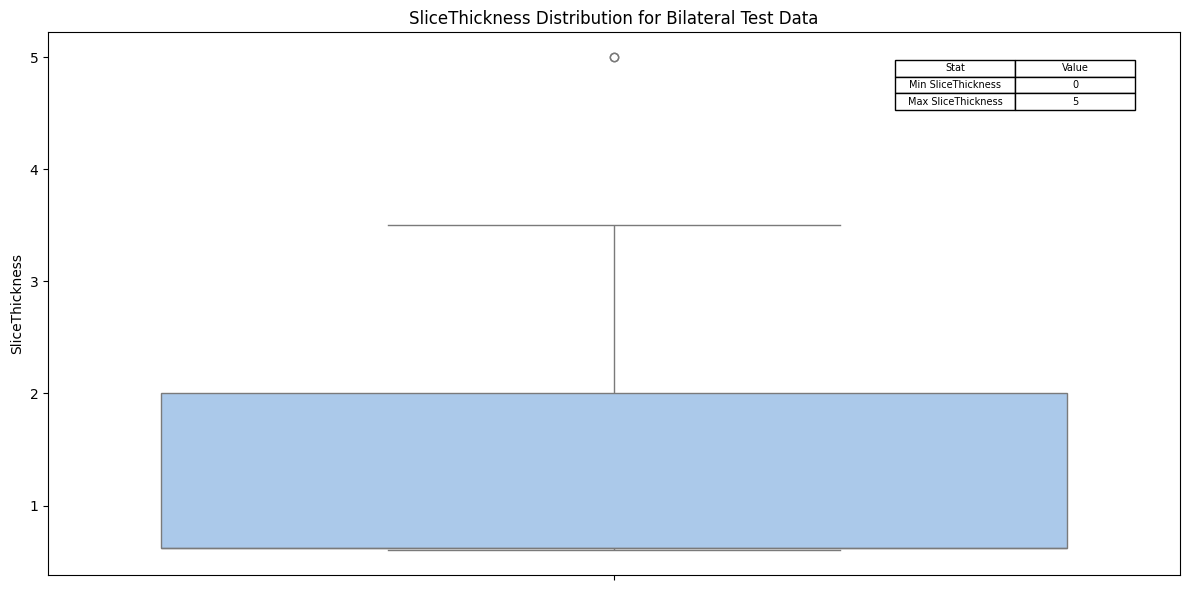

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Extract numeric age
df_unique = df.drop_duplicates(subset='PatientID', keep='first')
print("Total number of unique rows:", len(df_unique))

# Drop NaN ages
df_age_clean = df_unique.dropna(subset=['SliceThickness'])

# Calculate min and max age
min_age = df_age_clean['SliceThickness'].min()
max_age = df_age_clean['SliceThickness'].max()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_unique, y="SliceThickness", palette='pastel')
# Create a separate table figure (inset)
age_table = pd.DataFrame({
    'Stat': ['Min SliceThickness', 'Max SliceThickness'],
    'Value': [int(min_age), int(max_age)]
})

# Add table as a new axes
from matplotlib.transforms import Bbox
bbox = Bbox.from_bounds(0.75, 0.75, 0.2, 0.2)  # [left, bottom, width, height] in axes fraction
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=age_table.values,
               colLabels=age_table.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Final labels and layout
# ax.set_title('Age Distribution')
# ax.set_ylabel('Patients age')
# plt.tight_layout()
# plt.show()

title_name = f'SliceThickness Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_ylabel('SliceThickness')

# Save the figure
safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/697903363.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="RescaleIntercept", y="Count", data=RescaleIntercept_counts, palette='Set2', ax=ax)
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/697903363.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


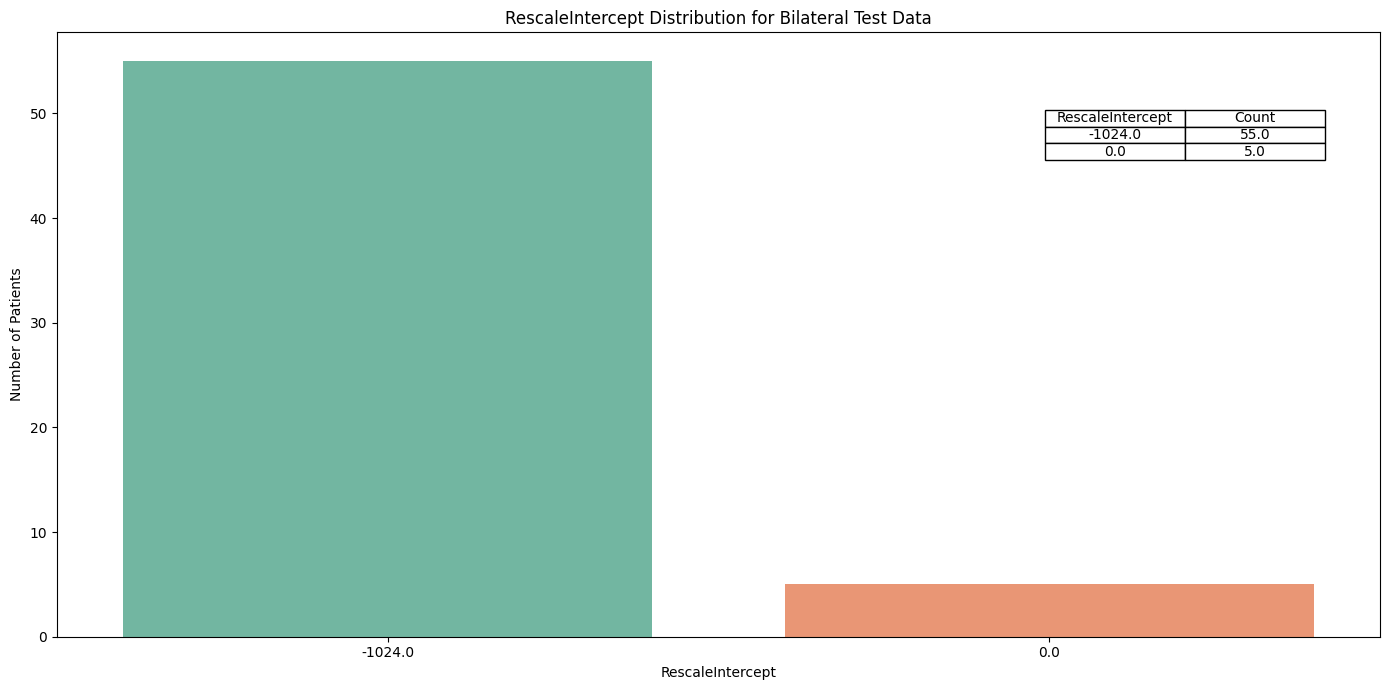

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox

# df_unique['RescaleIntercept'] = pd.to_datetime(df_unique['RescaleIntercept'], format='%Y%m%d')
earliest = df_unique['RescaleIntercept'].min()
latest = df_unique['RescaleIntercept'].max()

# Count the number of records per manufacturer
RescaleIntercept_counts = df_unique['RescaleIntercept'].value_counts().reset_index()
RescaleIntercept_counts.columns = ['RescaleIntercept', 'Count']

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x="RescaleIntercept", y="Count", data=RescaleIntercept_counts, palette='Set2', ax=ax)

# Create table inset with RescaleIntercept counts
bbox = Bbox.from_bounds(0.75, 0.65, 0.2, 0.3)  # Slightly bigger to accommodate more rows
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=RescaleIntercept_counts.values,
               colLabels=RescaleIntercept_counts.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Labels and save
title_name = f'RescaleIntercept Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_xlabel('RescaleIntercept')
ax.set_ylabel('Number of Patients')

safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2190383124.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Rows", y="Count", data=Rows_counts, palette='Set2', ax=ax)
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/2190383124.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


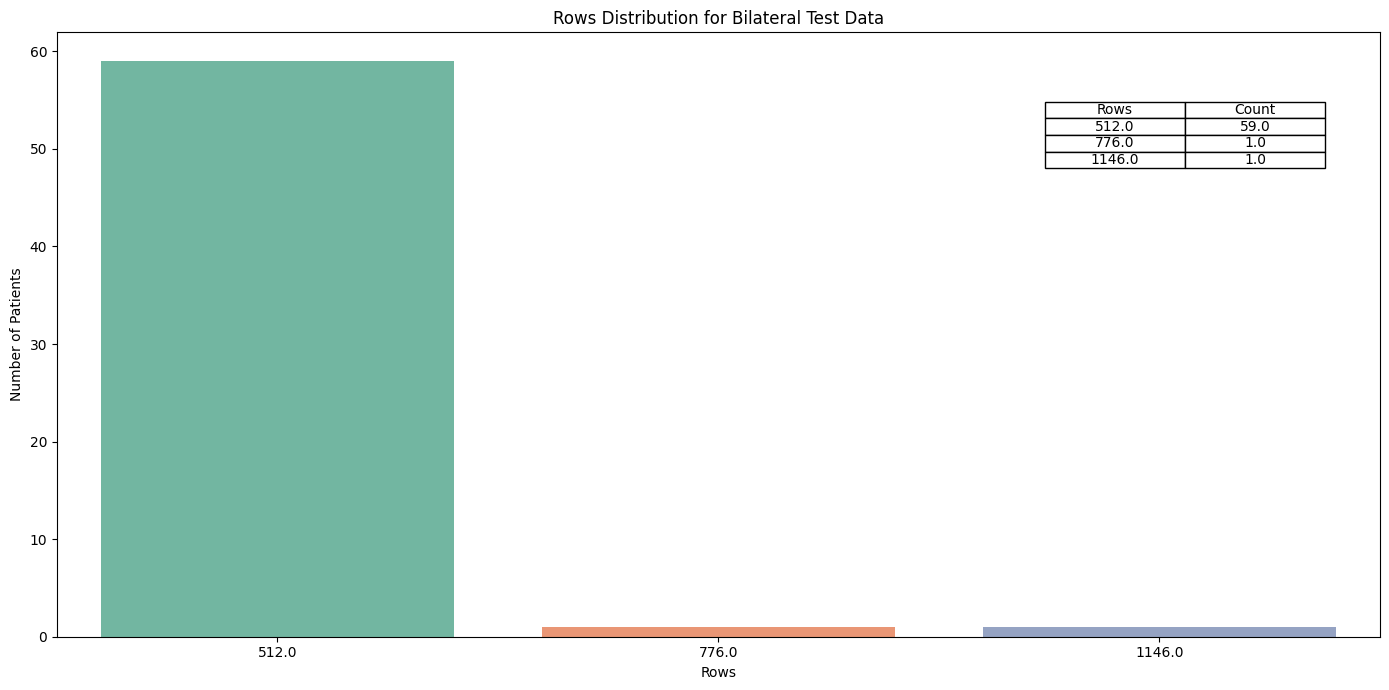

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox

# # Parse date
# df_unique['Rows'] = pd.to_datetime(df_unique['Rows'], format='%Y%m%d')
earliest = df_unique['Rows'].min()
latest = df_unique['Rows'].max()

# Count the number of records per manufacturer
Rows_counts = df_unique['Rows'].value_counts().reset_index()
Rows_counts.columns = ['Rows', 'Count']

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x="Rows", y="Count", data=Rows_counts, palette='Set2', ax=ax)

# Create table inset with Rows counts
bbox = Bbox.from_bounds(0.75, 0.65, 0.2, 0.3)  # Slightly bigger to accommodate more rows
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=Rows_counts.values,
               colLabels=Rows_counts.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Labels and save
title_name = f'Rows Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_xlabel('Rows')
ax.set_ylabel('Number of Patients')

safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()

/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/1283479032.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="KVP", y="Count", data=KVP_counts, palette='Set2', ax=ax)
/var/folders/c8/106_rczd17x4nxwn9bpg6cw00000gn/T/ipykernel_58405/1283479032.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


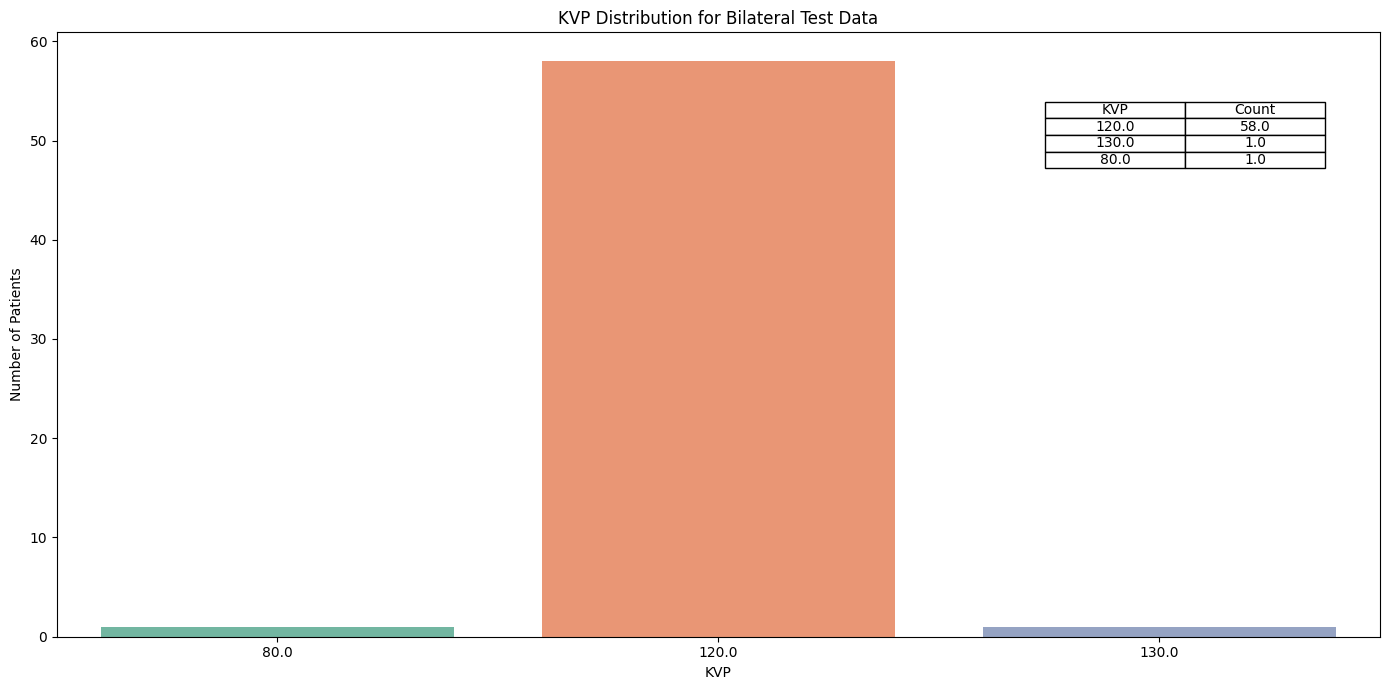

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox

# # Parse date
# df_unique['KVP'] = pd.to_datetime(df_unique['KVP'], format='%Y%m%d')
earliest = df_unique['KVP'].min()
latest = df_unique['KVP'].max()

# Count the number of records per manufacturer
KVP_counts = df_unique['KVP'].value_counts().reset_index()
KVP_counts.columns = ['KVP', 'Count']

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x="KVP", y="Count", data=KVP_counts, palette='Set2', ax=ax)

# Create table inset with KVP counts
bbox = Bbox.from_bounds(0.75, 0.65, 0.2, 0.3)  # Slightly bigger to accommodate more KVP
table_ax = fig.add_axes(bbox)
table_ax.axis('off')
table_ax.table(cellText=KVP_counts.values,
               colLabels=KVP_counts.columns,
               cellLoc='center',
               colLoc='center',
               loc='center')

# Labels and save
title_name = f'KVP Distribution for {plot_detail}'
ax.set_title(title_name)
ax.set_xlabel('KVP')
ax.set_ylabel('Number of Patients')

safe_title = title_name.replace(" ", "_")
plt.tight_layout()
plt.savefig(f"./{figure_save_dir}/{safe_title}.jpg", dpi=300)
plt.show()